In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("lwk.ibd.nodup.genome", delim_whitespace=True)

# Expected probability check
pc = df[(df["Z1"] > 0.9) & (df["Z0"] < 0.05) & (df["Z2"] < 0.05)].copy()
pc = pc.sort_values("PI_HAT", ascending=False)

sib = df[(df["Z1"] > 0.4) & (df["Z2"] > 0.10) & (df["Z0"] > 0.10)].copy()
sib = sib.sort_values("PI_HAT", ascending=False)

In [3]:
# ps2 Q3.3 results

print("Parent–child pairs:")
print(pc.to_string(index=False))

print("\nSibling pairs:")
print(sib.to_string(index=False))

Parent–child pairs:
   FID1    IID1    FID2    IID2 RT  EZ     Z0     Z1     Z2  PI_HAT  PHE      DST  PPC    RATIO
NA19445 NA19445 NA19453 NA19453 UN NaN 0.0029 0.9524 0.0447  0.5209   -1 0.850844  1.0 296.4375
NA19313 NA19313 NA19331 NA19331 UN NaN 0.0049 0.9546 0.0406  0.5178   -1 0.850021  1.0 214.1364
NA19469 NA19469 NA19470 NA19470 UN NaN 0.0041 0.9589 0.0369  0.5164   -1 0.849527  1.0 250.2105
NA19381 NA19381 NA19382 NA19382 UN NaN 0.0042 0.9606 0.0352  0.5155   -1 0.849253  1.0 366.0769

Sibling pairs:
   FID1    IID1    FID2    IID2 RT  EZ     Z0     Z1     Z2  PI_HAT  PHE      DST  PPC   RATIO
NA19347 NA19347 NA19352 NA19352 UN NaN 0.2087 0.5013 0.2900  0.5407   -1 0.869342  1.0 12.7135
NA19373 NA19373 NA19374 NA19374 UN NaN 0.2321 0.4664 0.3015  0.5347   -1 0.868882  1.0 11.6298
NA19396 NA19396 NA19397 NA19397 UN NaN 0.2240 0.5033 0.2727  0.5244   -1 0.865181  1.0 10.3607
NA19443 NA19443 NA19470 NA19470 UN NaN 0.2407 0.4773 0.2820  0.5207   -1 0.865033  1.0 10.2317
NA19434 N

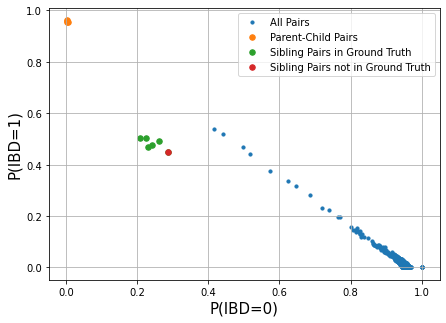

In [4]:
# visualization of P(IBD=0) vs. P(IBD=1)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.scatter(df["Z0"], df["Z1"], s=10, label="All Pairs")
ax.scatter(
    pc["Z0"],
    pc["Z1"],
    s=30,
    marker="o",
    label="Parent-Child Pairs"
)
ax.scatter(
    sib["Z0"],
    sib["Z1"],
    s=30,
    marker="o",
    label="Sibling Pairs in Ground Truth"
)
ax.scatter(
    [sib.iloc[-1]["Z0"]],
    [sib.iloc[-1]["Z1"]],
    s=30,
    marker="o",
    label="Sibling Pairs not in Ground Truth"
)

ax.set_xlabel("P(IBD=0)", size=15)
ax.set_ylabel("P(IBD=1)", size=15)
plt.grid()
plt.legend()